# 前処理結果分析ノートブック

このノートブックでは、前処理結果の妥当性を確認し、データの特徴を可視化します。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 1. 実験設定

In [2]:
# 実験名を設定
EXPERIMENT_NAME = "preprocess_v2_ws64"  # または "preprocess_v2_ws128"
DATA_DIR = Path("../output/experiments")
EXPERIMENT_DIR = DATA_DIR / EXPERIMENT_NAME

print(f"実験ディレクトリ: {EXPERIMENT_DIR}")
print(f"存在確認: {EXPERIMENT_DIR.exists()}")

実験ディレクトリ: ../output/experiments/preprocess_v2_ws64
存在確認: True


## 2. データ読み込み

In [3]:
def load_preprocessed_data(experiment_dir):
    """前処理済みデータを読み込み"""
    data = {}
    files = {
        'windows': 'train_windows.pkl',
        'demographics': 'train_demographics.pkl', 
        'tabular': 'train_tabular.pkl',
        'tof_voxel': 'train_tof_voxel.pkl',
        'tof_windows': 'train_tof_windows.pkl',
        'labels': 'train_labels.pkl',
        'info': 'train_info.pkl'
    }
    
    for key, filename in files.items():
        filepath = experiment_dir / 'preprocessed' / filename
        if filepath.exists():
            with open(filepath, 'rb') as f:
                data[key] = pickle.load(f)
            print(f"✅ {key}: {type(data[key])} - {getattr(data[key], 'shape', 'N/A')}")
        else:
            print(f"❌ {key}: ファイルが見つかりません")
    
    return data

# データ読み込み
data = load_preprocessed_data(EXPERIMENT_DIR)
print(f"\n読み込み完了: {len(data)}個のファイル")

✅ windows: <class 'numpy.ndarray'> - (10147, 64, 18)
✅ demographics: <class 'numpy.ndarray'> - (10147, 7)
✅ tabular: <class 'numpy.ndarray'> - (10147, 392)
✅ tof_voxel: <class 'numpy.ndarray'> - (574945, 5, 8, 8)
✅ tof_windows: <class 'numpy.ndarray'> - (10147, 64, 5, 8, 8)
✅ labels: <class 'numpy.ndarray'> - (10147,)
✅ info: <class 'list'> - N/A

読み込み完了: 7個のファイル


## 3. データ概要

In [4]:
print("📊 データ概要")
print("="*50)

for key, value in data.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape}")
        if np.issubdtype(value.dtype, np.number):
            print(f"  範囲: [{value.min():.3f}, {value.max():.3f}]")
            print(f"  平均: {value.mean():.3f}")
            print(f"  標準偏差: {value.std():.3f}")
    elif isinstance(value, (list, np.ndarray)):
        print(f"{key}: {np.array(value).shape}")
    else:
        print(f"{key}: {type(value)}")
    print()

📊 データ概要
windows: (10147, 64, 18)
  範囲: [-5.305, 5.340]
  平均: 0.000
  標準偏差: 1.000

demographics: (10147, 7)
  範囲: [-3.024, 6.302]
  平均: -0.000
  標準偏差: 1.000

tabular: (10147, 392)
  範囲: [-16.475, 100.727]
  平均: 0.000
  標準偏差: 0.860

tof_voxel: (574945, 5, 8, 8)
  範囲: [-0.864, 2.336]
  平均: -0.000
  標準偏差: 1.000

tof_windows: (10147, 64, 5, 8, 8)
  範囲: [-0.785, 2.454]
  平均: 0.000
  標準偏差: 1.000

labels: (10147,)
  範囲: [0.000, 17.000]
  平均: 8.117
  標準偏差: 5.062

info: (10147,)



## 4. ラベル分布分析

🏷️ ラベル分布
総サンプル数: 10147
ラベル数: 18


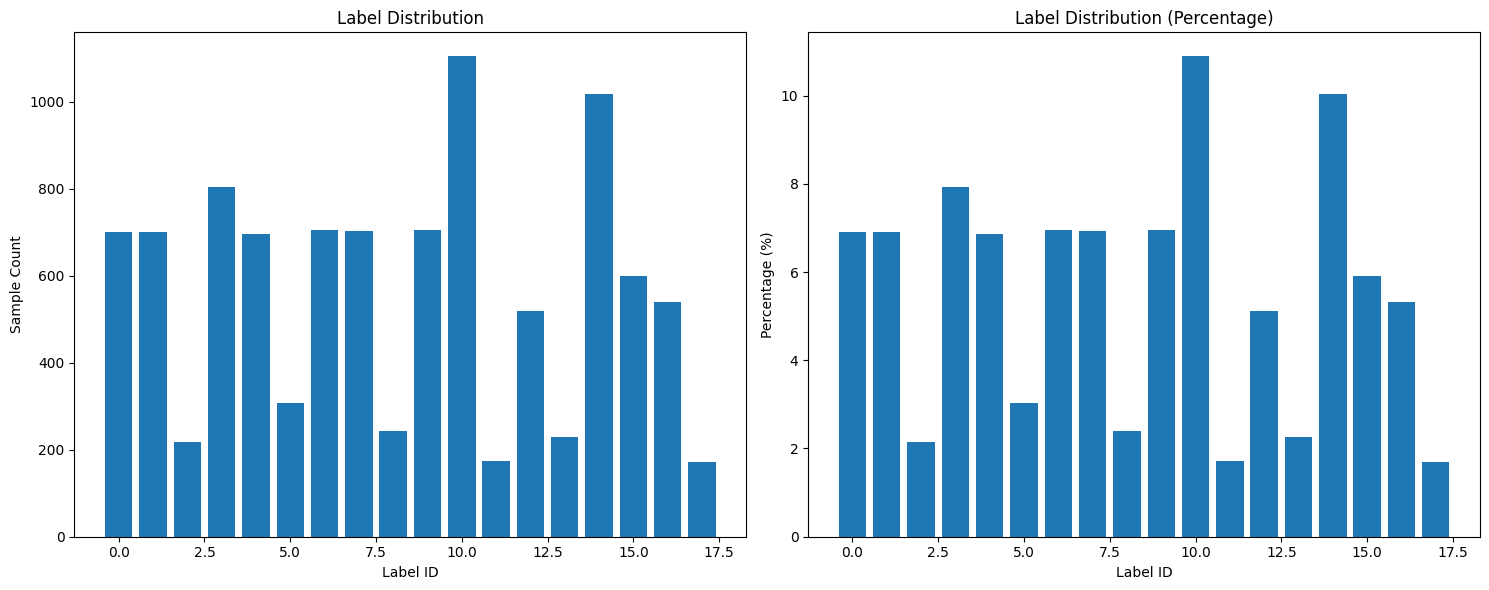


詳細統計:
  ラベル 0: 702 サンプル (6.9%)
  ラベル 1: 700 サンプル (6.9%)
  ラベル 2: 219 サンプル (2.2%)
  ラベル 3: 804 サンプル (7.9%)
  ラベル 4: 697 サンプル (6.9%)
  ラベル 5: 307 サンプル (3.0%)
  ラベル 6: 705 サンプル (6.9%)
  ラベル 7: 704 サンプル (6.9%)
  ラベル 8: 243 サンプル (2.4%)
  ラベル 9: 705 サンプル (6.9%)
  ラベル 10: 1105 サンプル (10.9%)
  ラベル 11: 175 サンプル (1.7%)
  ラベル 12: 519 サンプル (5.1%)
  ラベル 13: 229 サンプル (2.3%)
  ラベル 14: 1019 サンプル (10.0%)
  ラベル 15: 600 サンプル (5.9%)
  ラベル 16: 541 サンプル (5.3%)
  ラベル 17: 173 サンプル (1.7%)

クラス不均衡比: 6.39
✅ クラス分布は比較的均等です


In [5]:
if 'labels' in data:
    labels = data['labels']
    unique, counts = np.unique(labels, return_counts=True)
    
    print(f"🏷️ ラベル分布")
    print(f"総サンプル数: {len(labels)}")
    print(f"ラベル数: {len(unique)}")
    
    # ラベル分布の可視化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar graph
    ax1.bar(unique, counts)
    ax1.set_title('Label Distribution')
    ax1.set_xlabel('Label ID')
    ax1.set_ylabel('Sample Count')
    
    # パーセンテージ表示
    percentages = counts / len(labels) * 100
    ax2.bar(unique, percentages)
    ax2.set_title('Label Distribution (Percentage)')
    ax2.set_xlabel('Label ID')
    ax2.set_ylabel('Percentage (%)')
    
    plt.tight_layout()
    plt.show()
    
    # 詳細統計
    print("\n詳細統計:")
    for label, count, pct in zip(unique, counts, percentages):
        print(f"  ラベル {label}: {count} サンプル ({pct:.1f}%)")
    
    # クラス不均衡チェック
    min_count = counts.min()
    max_count = counts.max()
    imbalance_ratio = max_count / min_count
    print(f"\nクラス不均衡比: {imbalance_ratio:.2f}")
    
    if imbalance_ratio > 10:
        print("⚠️ クラス不均衡が大きいです")
    else:
        print("✅ クラス分布は比較的均等です")

## 5. センサーデータ分析

📡 センサーデータ分析
形状: (10147, 64, 18)
データ型: float32

基本統計:
平均: 0.000
標準偏差: 1.000
最小値: -5.305
最大値: 5.340
✅ 欠損値: なし


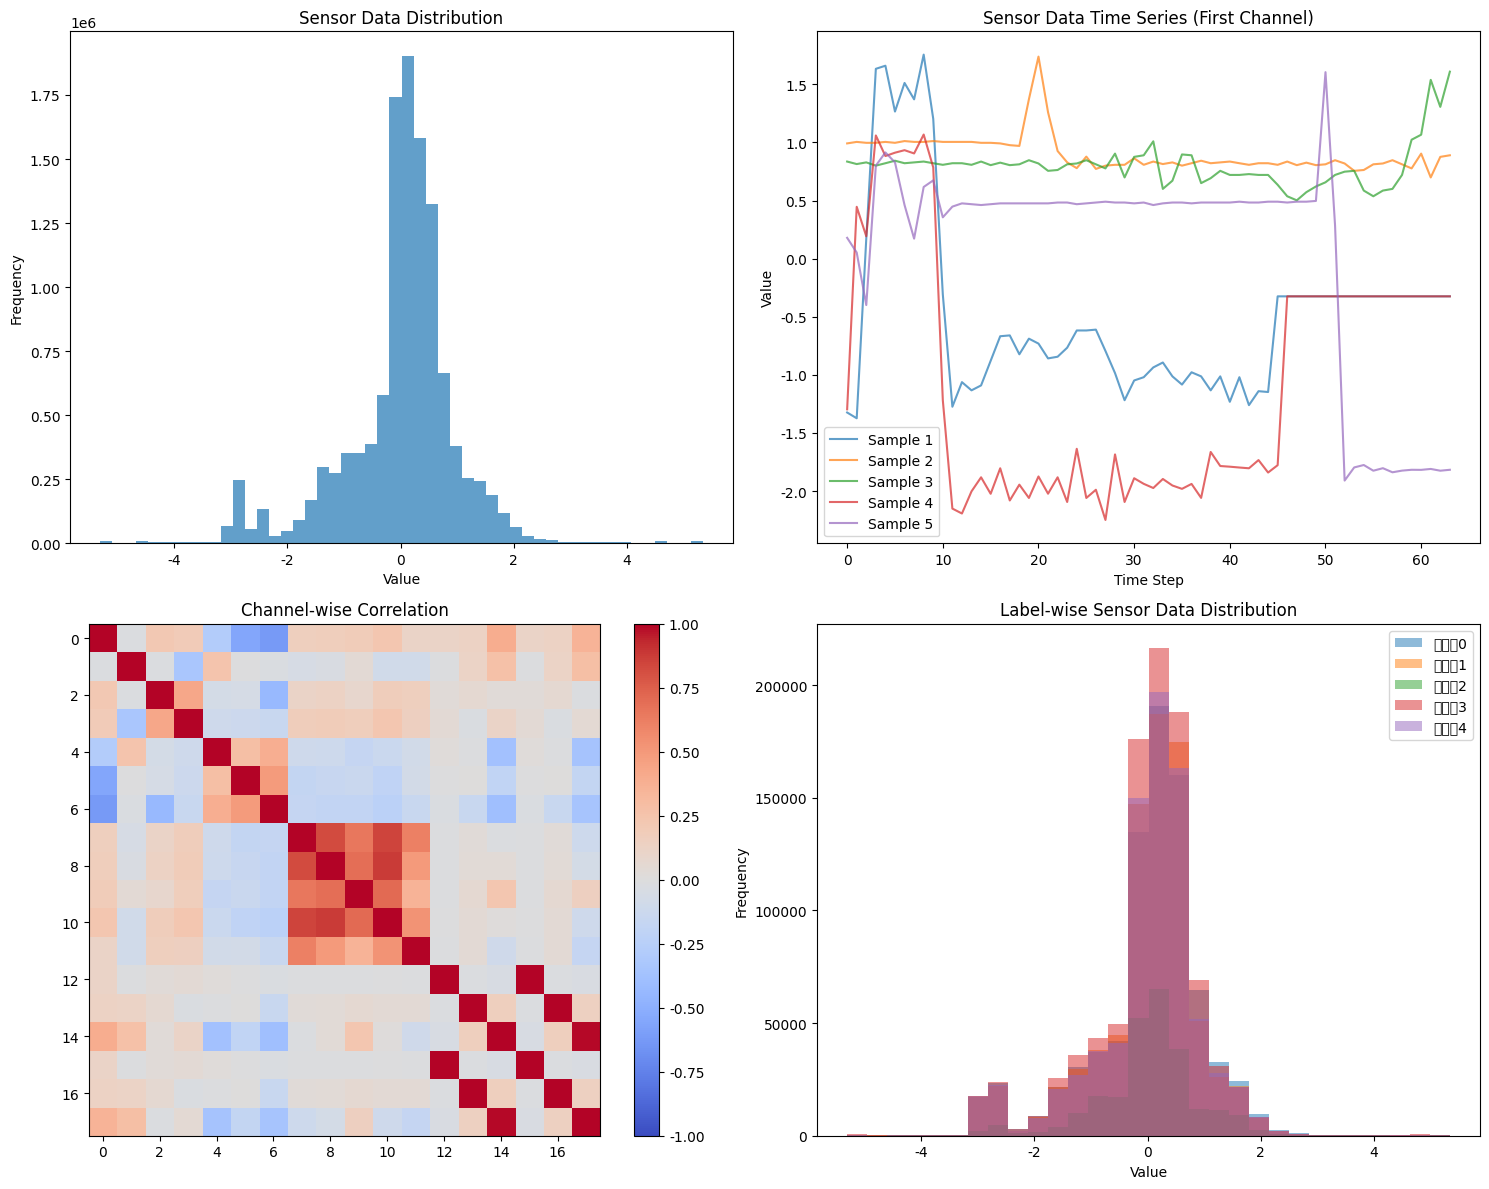

In [6]:
if 'windows' in data:
    windows = data['windows']
    
    print(f"📡 センサーデータ分析")
    print(f"形状: {windows.shape}")
    print(f"データ型: {windows.dtype}")
    
    # 基本統計
    print(f"\n基本統計:")
    print(f"平均: {windows.mean():.3f}")
    print(f"標準偏差: {windows.std():.3f}")
    print(f"最小値: {windows.min():.3f}")
    print(f"最大値: {windows.max():.3f}")
    
    # 欠損値チェック
    if np.isnan(windows).any():
        missing_count = np.isnan(windows).sum()
        print(f"⚠️ 欠損値: {missing_count}個")
    else:
        print(f"✅ 欠損値: なし")
    
    # 可視化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Data distribution
    axes[0, 0].hist(windows.flatten(), bins=50, alpha=0.7)
    axes[0, 0].set_title('Sensor Data Distribution')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # 2. 時系列プロット（最初の5サンプル）
    n_samples = min(5, windows.shape[0])
    for i in range(n_samples):
        axes[0, 1].plot(windows[i, :, 0], alpha=0.7, label=f'Sample {i+1}')
    axes[0, 1].set_title('Sensor Data Time Series (First Channel)')
    axes[0, 1].set_xlabel('Time Step')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].legend()
    
    # 3. チャンネル間相関
    if windows.shape[2] > 1:
        sample_means = windows.mean(axis=1)
        corr_matrix = np.corrcoef(sample_means.T)
        im = axes[1, 0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
        axes[1, 0].set_title('Channel-wise Correlation')
        plt.colorbar(im, ax=axes[1, 0])
    
    # 4. ラベル別分布
    if 'labels' in data:
        labels = data['labels']
        unique_labels = np.unique(labels)
        n_labels = min(5, len(unique_labels))
        
        for i, label in enumerate(unique_labels[:n_labels]):
            mask = labels == label
            if mask.sum() > 0:
                label_data = windows[mask].flatten()
                axes[1, 1].hist(label_data, bins=30, alpha=0.5, label=f'ラベル{label}')
        
        axes[1, 1].set_title('Label-wise Sensor Data Distribution')
        axes[1, 1].set_xlabel('Value')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

## 6. ToFデータ分析

📷 ToFデータ分析
形状: (10147, 64, 5, 8, 8)
データ型: float32

基本統計:
平均: 0.000
標準偏差: 1.000
最小値: -0.785
最大値: 2.454
⚠️ 負の値: 126851256個


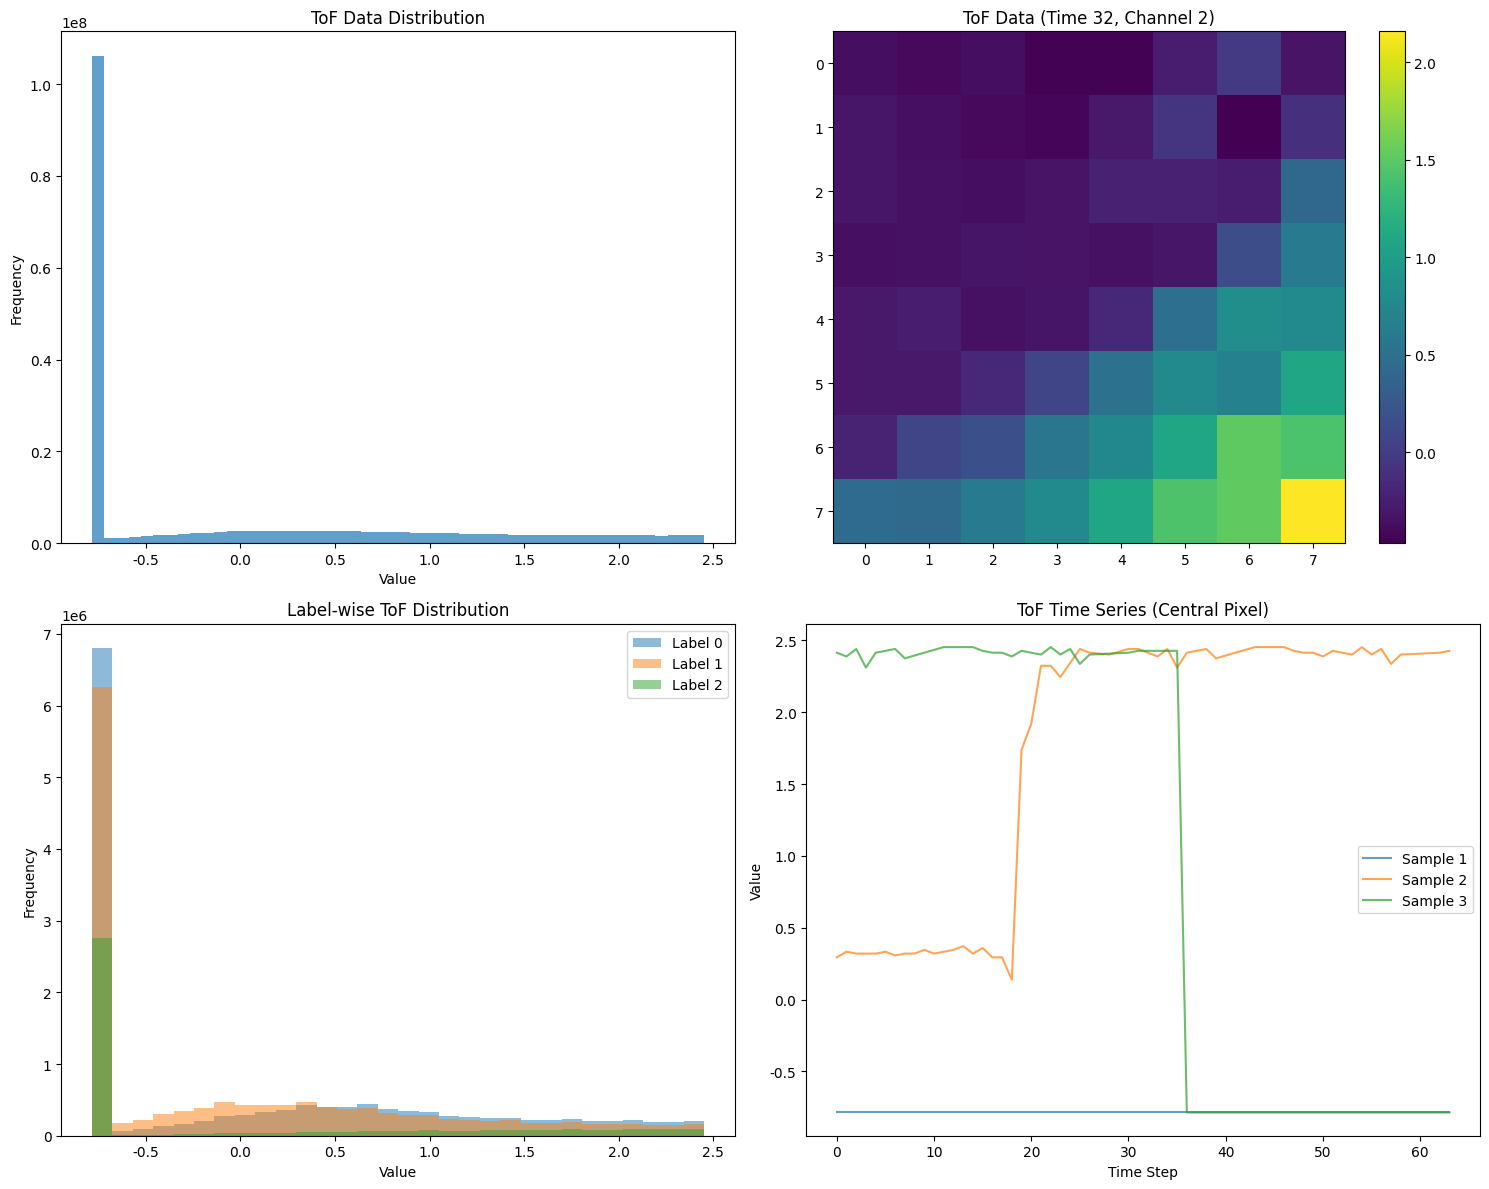

In [7]:
if 'tof_windows' in data:
    tof_windows = data['tof_windows']
    
    print(f"📷 ToFデータ分析")
    print(f"形状: {tof_windows.shape}")
    print(f"データ型: {tof_windows.dtype}")
    
    # 基本統計
    print(f"\n基本統計:")
    print(f"平均: {tof_windows.mean():.3f}")
    print(f"標準偏差: {tof_windows.std():.3f}")
    print(f"最小値: {tof_windows.min():.3f}")
    print(f"最大値: {tof_windows.max():.3f}")
    
    # 負の値チェック
    if (tof_windows < 0).any():
        negative_count = (tof_windows < 0).sum()
        print(f"⚠️ 負の値: {negative_count}個")
    else:
        print(f"✅ 負の値: なし")
    
    # 可視化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. データ分布
    axes[0, 0].hist(tof_windows.flatten(), bins=50, alpha=0.7)
    axes[0, 0].set_title('ToF Data Distribution')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # 2. ToF画像表示（最初のサンプル）
    if tof_windows.shape[0] > 0:
        sample_tof = tof_windows[0]
        mid_time = sample_tof.shape[0] // 2
        mid_channel = sample_tof.shape[1] // 2
        
        im = axes[0, 1].imshow(sample_tof[mid_time, mid_channel], cmap='viridis')
        axes[0, 1].set_title(f'ToF Data (Time {mid_time}, Channel {mid_channel})')
        plt.colorbar(im, ax=axes[0, 1])
    
    # 3. ラベル別分布
    if 'labels' in data:
        labels = data['labels']
        unique_labels = np.unique(labels)
        n_labels = min(3, len(unique_labels))
        
        for i, label in enumerate(unique_labels[:n_labels]):
            mask = labels == label
            if mask.sum() > 0:
                label_tof = tof_windows[mask].flatten()
                axes[1, 0].hist(label_tof, bins=30, alpha=0.5, label=f'Label {label}')
        
        axes[1, 0].set_title('Label-wise ToF Distribution')
        axes[1, 0].set_xlabel('Value')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()
    
    # 4. 時系列プロット（最初のチャンネルの平均）
    if tof_windows.shape[0] > 0:
        time_series = tof_windows[:, :, 0, 0, 0]  # 最初のチャンネルの中央ピクセル
        n_samples = min(3, time_series.shape[0])
        for i in range(n_samples):
            axes[1, 1].plot(time_series[i], alpha=0.7, label=f'Sample {i+1}')
        axes[1, 1].set_title('ToF Time Series (Central Pixel)')
        axes[1, 1].set_xlabel('Time Step')
        axes[1, 1].set_ylabel('Value')
        axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

## 7. タブラーデータ分析

📋 タブラーデータ分析
形状: (10147, 392)
データ型: float64

基本統計:
平均: 0.000
標準偏差: 0.860
最小値: -16.475
最大値: 100.727


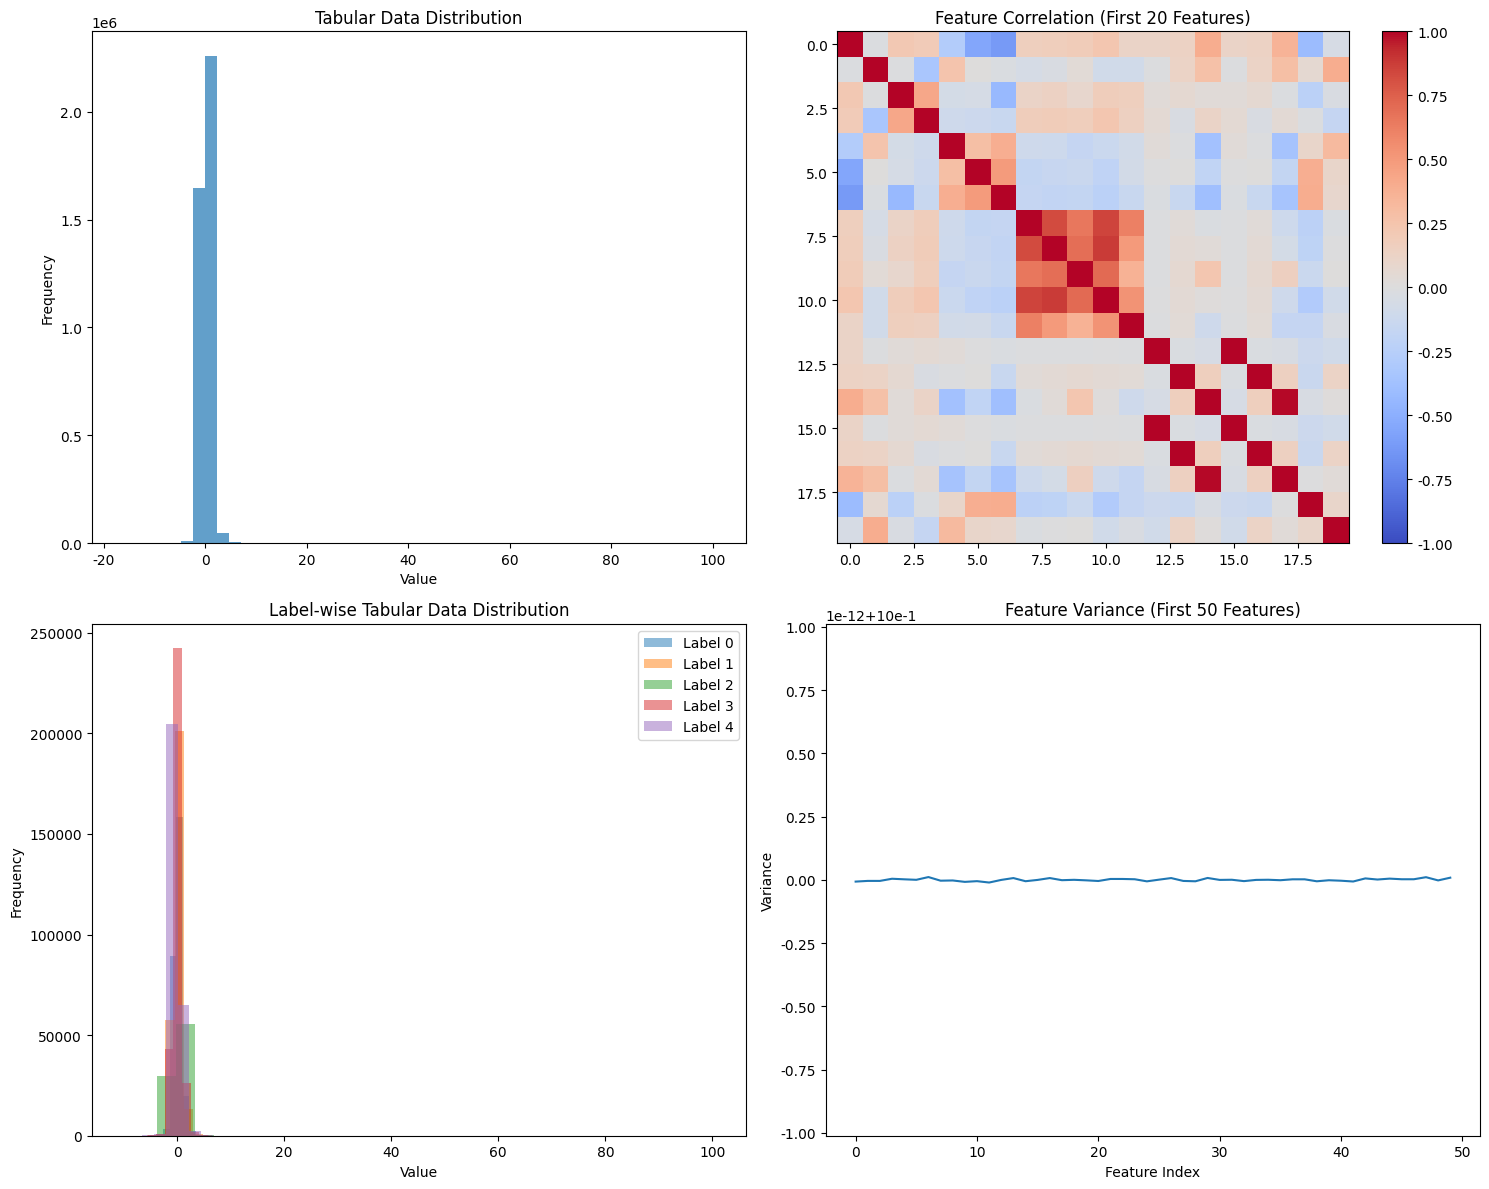

In [8]:
if 'tabular' in data:
    tabular = data['tabular']
    
    print(f"📋 タブラーデータ分析")
    print(f"形状: {tabular.shape}")
    print(f"データ型: {tabular.dtype}")
    
    # 基本統計
    print(f"\n基本統計:")
    print(f"平均: {tabular.mean():.3f}")
    print(f"標準偏差: {tabular.std():.3f}")
    print(f"最小値: {tabular.min():.3f}")
    print(f"最大値: {tabular.max():.3f}")
    
    # 可視化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. データ分布
    axes[0, 0].hist(tabular.flatten(), bins=50, alpha=0.7)
    axes[0, 0].set_title('Tabular Data Distribution')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # 2. 特徴量間相関（最初の20特徴量）
    n_features = min(20, tabular.shape[1])
    corr_matrix = np.corrcoef(tabular[:, :n_features].T)
    im = axes[0, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    axes[0, 1].set_title(f'Feature Correlation (First {n_features} Features)')
    plt.colorbar(im, ax=axes[0, 1])
    
    # 3. ラベル別分布
    if 'labels' in data:
        labels = data['labels']
        unique_labels = np.unique(labels)
        n_labels = min(5, len(unique_labels))
        
        for i, label in enumerate(unique_labels[:n_labels]):
            mask = labels == label
            if mask.sum() > 0:
                label_tabular = tabular[mask].flatten()
                axes[1, 0].hist(label_tabular, bins=30, alpha=0.5, label=f'Label {label}')
        
        axes[1, 0].set_title('Label-wise Tabular Data Distribution')
        axes[1, 0].set_xlabel('Value')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()
    
    # 4. 特徴量の分散
    feature_vars = np.var(tabular, axis=0)
    axes[1, 1].plot(feature_vars[:50])  # 最初の50特徴量
    axes[1, 1].set_title('Feature Variance (First 50 Features)')
    axes[1, 1].set_xlabel('Feature Index')
    axes[1, 1].set_ylabel('Variance')
    
    plt.tight_layout()
    plt.show()

(10147, 392)


NameError: name 'feature_names' is not defined

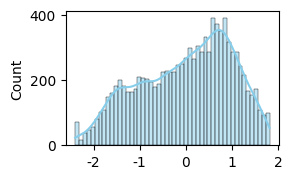

In [ ]:
from pathlib import Path
import pickle

# 実験名を指定（例: "exp1"）
experiment_name = "preprocess_v2_ws64"

# 保存先ディレクトリ
pre_dir = Path(f"../output/experiments/{experiment_name}/preprocessed")

# 正規化後tabular特徴量の読み込み
with open(pre_dir / "train_tabular.pkl", "rb") as f:
    norm_tabular = pickle.load(f)

print(norm_tabular.shape)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# norm_tabular: 正規化後のtabular特徴量 (np.ndarray)
# feature_names: 特徴量名リスト（なければNoneでOK）
feature_names= None

# 可視化する特徴量数（例：最初の20個）
n_features = 20
plt.figure(figsize=(16, 8))
for i in range(n_features):
    plt.subplot(4, 5, i+1)
    sns.histplot(norm_tabular[:, i], bins=50, color='skyblue', kde=True)
    plt.title(feature_names[i] if feature_names else f'Feature {i}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Distribution of First 20 Tabular Features (Normalized)', y=1.02)
plt.show()

# --- 全特徴量の分布の外れ値傾向をざっくり確認 ---
feature_max = np.max(norm_tabular, axis=0)
feature_min = np.min(norm_tabular, axis=0)
feature_mean = np.mean(norm_tabular, axis=0)
feature_std = np.std(norm_tabular, axis=0)

plt.figure(figsize=(12, 4))
plt.plot(feature_max, label='max')
plt.plot(feature_min, label='min')
plt.plot(feature_mean, label='mean')
plt.plot(feature_std, label='std')
plt.title('Summary Statistics of All Tabular Features (Normalized)')
plt.xlabel('Feature Index')
plt.legend()
plt.show()

# --- 外れ値の有無をざっくり判定 ---
outlier_count = np.sum((np.abs(norm_tabular) > 5), axis=0)  # z-scoreで5を超える値
plt.figure(figsize=(12, 3))
plt.bar(np.arange(norm_tabular.shape[1]), outlier_count)
plt.title('Number of Outliers (|z| > 5) per Feature')
plt.xlabel('Feature Index')
plt.ylabel('Count')
plt.show()

## 8. データ品質チェック

In [9]:
print("🔍 データ品質チェック")
print("="*50)

# サンプル数整合性チェック
sample_counts = {}
for key, value in data.items():
    if hasattr(value, 'shape'):
        sample_counts[key] = value.shape[0]
    elif isinstance(value, (list, np.ndarray)):
        sample_counts[key] = len(value)

print("📊 サンプル数整合性:")
if sample_counts:
    base_count = list(sample_counts.values())[0]
    for key, count in sample_counts.items():
        status = "✅" if count == base_count else "❌"
        print(f"  {status} {key}: {count}")

# 欠損値チェック
print("\n🔍 欠損値チェック:")
for key, value in data.items():
    if hasattr(value, 'shape'):
        if np.isnan(value).any():
            missing_count = np.isnan(value).sum()
            print(f"  ❌ {key}: {missing_count}個の欠損値")
        else:
            print(f"  ✅ {key}: 欠損値なし")

# 異常値チェック（Z-score法）
print("\n🔍 異常値チェック（Z-score > 3）:")
for key, value in data.items():
    if hasattr(value, 'shape') and np.issubdtype(value.dtype, np.number):
        z_scores = np.abs((value - value.mean()) / value.std())
        outlier_count = (z_scores > 3).sum()
        outlier_ratio = outlier_count / value.size * 100
        if outlier_count > 0:
            print(f"  ⚠️ {key}: {outlier_count}個 ({outlier_ratio:.2f}%)")
        else:
            print(f"  ✅ {key}: 異常値なし")

print("\n✅ データ品質チェック完了")

🔍 データ品質チェック
📊 サンプル数整合性:
  ✅ windows: 10147
  ✅ demographics: 10147
  ✅ tabular: 10147
  ❌ tof_voxel: 574945
  ✅ tof_windows: 10147
  ✅ labels: 10147
  ✅ info: 10147

🔍 欠損値チェック:
  ✅ windows: 欠損値なし
  ✅ demographics: 欠損値なし
  ✅ tabular: 欠損値なし
  ✅ tof_voxel: 欠損値なし
  ✅ tof_windows: 欠損値なし
  ✅ labels: 欠損値なし

🔍 異常値チェック（Z-score > 3）:
  ⚠️ windows: 148490個 (1.27%)
  ⚠️ demographics: 350個 (0.49%)
  ⚠️ tabular: 53217個 (1.34%)
  ✅ tof_voxel: 異常値なし
  ✅ tof_windows: 異常値なし
  ✅ labels: 異常値なし

✅ データ品質チェック完了


## 9. サマリー

In [10]:
print("📋 前処理結果サマリー")
print("="*50)

# データ概要
print("📊 データ概要:")
for key, value in data.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    elif isinstance(value, (list, np.ndarray)):
        print(f"  {key}: {np.array(value).shape}")

# ラベル情報
if 'labels' in data:
    labels = data['labels']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n🏷️ ラベル情報:")
    print(f"  総サンプル数: {len(labels)}")
    print(f"  ラベル数: {len(unique)}")
    print(f"  クラス不均衡比: {counts.max() / counts.min():.2f}")

# 統計情報
print(f"\n📈 統計情報:")
if 'windows' in data:
    windows = data['windows']
    print(f"  センサーデータ平均: {windows.mean():.3f}")
    print(f"  センサーデータ標準偏差: {windows.std():.3f}")

if 'tof_windows' in data:
    tof_windows = data['tof_windows']
    print(f"  ToFデータ平均: {tof_windows.mean():.3f}")
    print(f"  ToFデータ標準偏差: {tof_windows.std():.3f}")

if 'tabular' in data:
    tabular = data['tabular']
    print(f"  タブラーデータ平均: {tabular.mean():.3f}")
    print(f"  タブラーデータ標準偏差: {tabular.std():.3f}")

print("\n✅ 前処理結果の確認が完了しました！")

📋 前処理結果サマリー
📊 データ概要:
  windows: (10147, 64, 18)
  demographics: (10147, 7)
  tabular: (10147, 392)
  tof_voxel: (574945, 5, 8, 8)
  tof_windows: (10147, 64, 5, 8, 8)
  labels: (10147,)
  info: (10147,)

🏷️ ラベル情報:
  総サンプル数: 10147
  ラベル数: 18
  クラス不均衡比: 6.39

📈 統計情報:
  センサーデータ平均: 0.000
  センサーデータ標準偏差: 1.000
  ToFデータ平均: 0.000
  ToFデータ標準偏差: 1.000
  タブラーデータ平均: 0.000
  タブラーデータ標準偏差: 0.860

✅ 前処理結果の確認が完了しました！
